## car price predicction

### import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## the data set

In [2]:
data = pd.read_csv("car_price_prediction_.csv")
data.head()


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


### check data info

In [3]:
print(data.shape)
print(data.columns)
print(data.info())


(2500, 10)
Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB
None


## data cleaning

##### check missing values

In [4]:
data.isnull().sum()


Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

#### convert year to car age

In [5]:
data['Car_Age'] = 2025 - data['Year']
data.drop('Year', axis=1, inplace=True)


### EDA

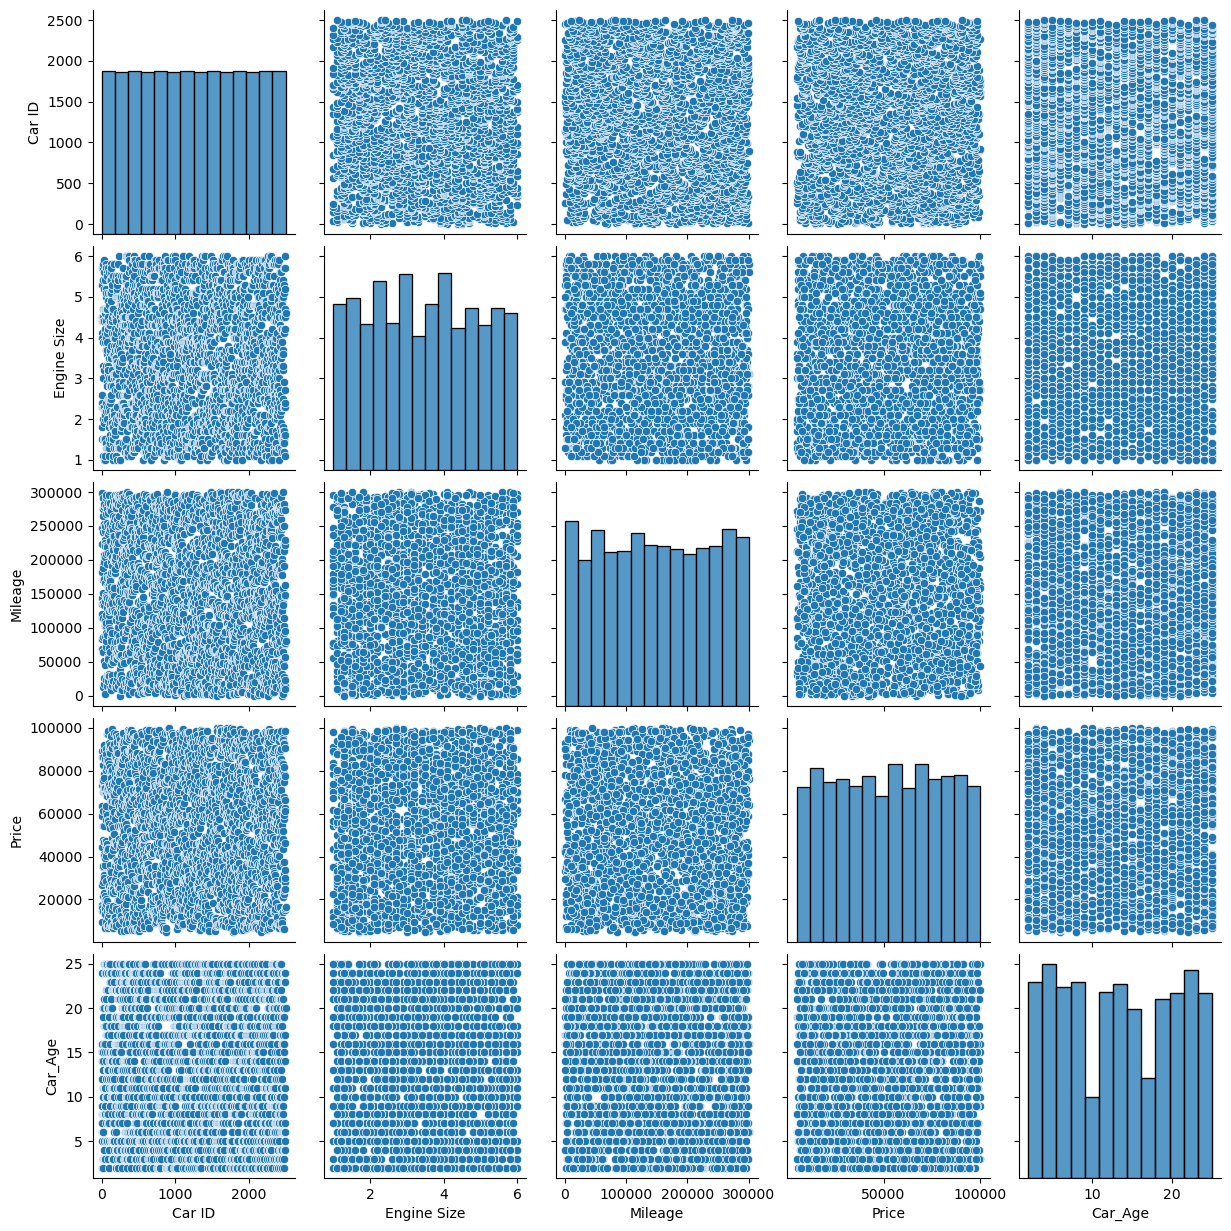

In [6]:
sns.pairplot(data)
plt.show()


#### feature encoding

In [7]:
data = pd.get_dummies(data, drop_first=True)


In [8]:
y = data['Price']
X = data.drop('Price', axis=1)


### train -test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# Decision Tree Regression (safe: ensures train/test split exists)
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
# If train/test split variables are not defined (cell run order), create them
try:
    X_train
except NameError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
DTR_Accuracy = round(r2_score(y_test, model.predict(X_test)) * 100)
DTR_Accuracy

-100

In [11]:
# support vector regression
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
SVR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
SVR_Accuracy

0

In [12]:
# support vector regression
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
SVR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
SVR_Accuracy

0

In [13]:
# random forese regressor with estimate
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(n_estimators=10)
RF_model.fit(X_train, y_train)
from sklearn.metrics import r2_score
RFR_Accuracy=round(r2_score(y_test, RF_model.predict(X_test)) * 100)
RFR_Accuracy

-14

In [14]:

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
from sklearn.linear_model import LinearRegression
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
from sklearn.metrics import r2_score
PR_Accuracy=round(r2_score(y_test, poly_model.predict(X_test_poly)) * 100)
PR_Accuracy

-22

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr_model = LinearRegression()
try:
    X_train
except NameError:
    try:
        X
        y
    except NameError:
        import pandas as pd
        data = pd.read_csv("car_price_prediction_.csv")
        data['Car_Age'] = 2025 - data['Year']
        data.drop('Year', axis=1, inplace=True)
        data = pd.get_dummies(data, drop_first=True)
        y = data['Price']
        X = data.drop('Price', axis=1)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model.fit(X_train, y_train)
LR_Accuracy = round(r2_score(y_test, lr_model.predict(X_test)) * 100)
LR_Accuracy


-2

C:\Users\bonag\AppData\Local\Temp\ipykernel_19620\2649610214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Accuracy, y=models, palette='pastel')


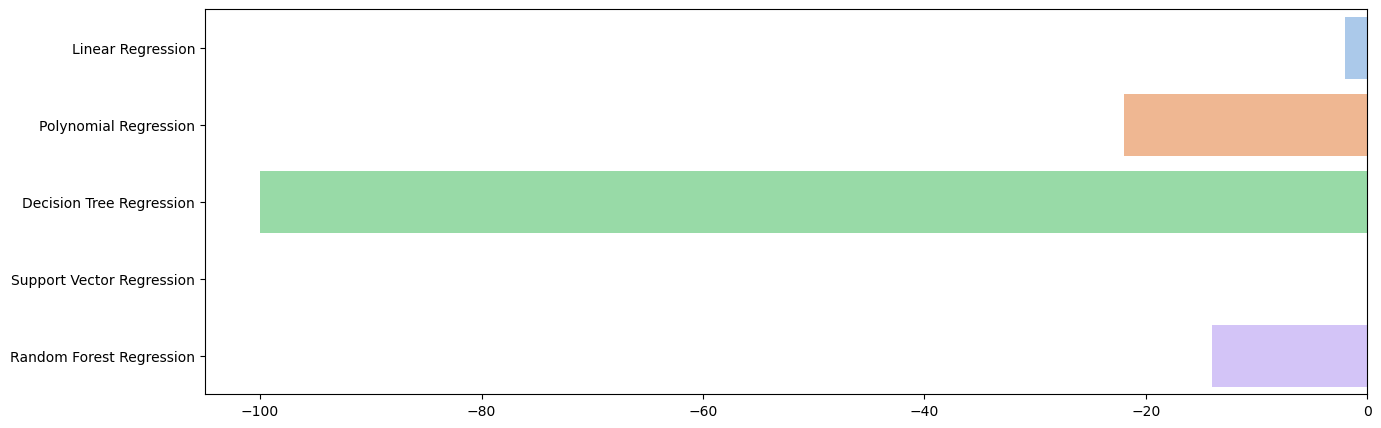

In [16]:
models = ["Linear Regression", "Polynomial Regression", "Decision Tree Regression", "Support Vector Regression", "Random Forest Regression"]
Accuracy = [LR_Accuracy,PR_Accuracy, DTR_Accuracy, SVR_Accuracy, RFR_Accuracy]
plt.figure(figsize=(15, 5))
sns.barplot(x=Accuracy, y=models, palette='pastel')
plt.show()

#### train model

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### evalute model

In [18]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: -0.020169658180126504


#### save 

In [19]:
import pickle

with open("model_columns.pkl", "wb") as file:
    pickle.dump(X.columns, file)

print("Model columns saved successfully!")

Model columns saved successfully!


In [20]:
with open("car_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")


Model loaded successfully!


In [21]:
import pickle

# Save the trained model
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")


Model saved successfully!


In [22]:
# Load saved model and provide a prediction helper
import pickle
import pandas as pd
with open("car_price_model.pkl", "rb") as f:
    model = pickle.load(f)

def predict_price(sample_dict):
    df = pd.DataFrame([sample_dict])
    if 'Year' in df.columns:
        df['Car_Age'] = 2025 - df['Year']
        df = df.drop('Year', axis=1)
    try:
        X_cols = X.columns
    except NameError:
        data_ref = pd.read_csv("car_price_prediction_.csv")
        data_ref['Car_Age'] = 2025 - data_ref['Year']
        data_ref = data_ref.drop('Year', axis=1)
        data_ref = pd.get_dummies(data_ref, drop_first=True)
        X_cols = data_ref.drop('Price', axis=1).columns
    df = pd.get_dummies(df)
    for c in X_cols:
        if c not in df.columns:
            df[c] = 0
    df = df[list(X_cols)]
    return model.predict(df)[0]

# Example: predict using first test sample when available
try:
    sample = X_test.iloc[0].to_dict()
    print('Example sample (first test row):')
    print(sample)
    print('Predicted price:', predict_price(sample))
except Exception as e:
    print('Example prediction unavailable:', e)


Example sample (first test row):
{'Car ID': 1448, 'Engine Size': 3.0, 'Mileage': 211864, 'Car_Age': 15, 'Brand_BMW': False, 'Brand_Ford': False, 'Brand_Honda': True, 'Brand_Mercedes': False, 'Brand_Tesla': False, 'Brand_Toyota': False, 'Fuel Type_Electric': False, 'Fuel Type_Hybrid': False, 'Fuel Type_Petrol': False, 'Transmission_Manual': True, 'Condition_New': False, 'Condition_Used': False, 'Model_5 Series': False, 'Model_A3': False, 'Model_A4': False, 'Model_Accord': False, 'Model_C-Class': False, 'Model_CR-V': False, 'Model_Camry': False, 'Model_Civic': False, 'Model_Corolla': False, 'Model_E-Class': False, 'Model_Explorer': False, 'Model_Fiesta': False, 'Model_Fit': True, 'Model_Focus': False, 'Model_GLA': False, 'Model_GLC': False, 'Model_Model 3': False, 'Model_Model S': False, 'Model_Model X': False, 'Model_Model Y': False, 'Model_Mustang': False, 'Model_Prius': False, 'Model_Q5': False, 'Model_Q7': False, 'Model_RAV4': False, 'Model_X3': False, 'Model_X5': False}
Predicted pr

In [23]:
# save random forest model
import pickle
pickle.dump(RF_model, open('RF_model.pkl', 'wb'))

In [24]:
# Save scaler parameters safely: check for existing scaler or fit one if missing
import pickle
from sklearn.preprocessing import StandardScaler
import pandas as pd
# Prefer variable name 'scaler', fall back to 'scalar' if present
if 'scaler' in globals():
    sc = globals()['scaler']
elif 'scalar' in globals():
    sc = globals()['scalar']
else:
    sc = StandardScaler()
    try:
        sc.fit(X_train)
    except Exception:
        try:
            sc.fit(X)
        except Exception:
            # As a last resort, load data and prepare features to fit scaler
            data_ref = pd.read_csv("car_price_prediction_.csv")
            if 'Year' in data_ref.columns:
                data_ref['Car_Age'] = 2025 - data_ref['Year']
                data_ref = data_ref.drop('Year', axis=1)
            data_ref = pd.get_dummies(data_ref, drop_first=True)
            if 'Price' in data_ref.columns:
                X_fit = data_ref.drop('Price', axis=1)
            else:
                X_fit = data_ref
            sc.fit(X_fit)
# Persist scaler
pickle.dump(sc, open('scaler.pkl', 'wb'))
print('Scaler saved to scaler.pkl')

Scaler saved to scaler.pkl


### conclusion